# Van de Vusse CSTR — Mechanistic Model
### CHE 891 — Week 3

This notebook implements the Van de Vusse CSTR model from Velioglu et al. (2025),
Eqs. 3a–3d and Table 2, using `scipy.integrate.solve_ivp`.

**Reaction scheme** (van de Vusse, 1964):
$$A \xrightarrow{k_1} B \xrightarrow{k_2} C, \qquad 2A \xrightarrow{k_3} D$$

$B$ is the desired product; $C$ and $D$ are unwanted byproducts.

**States:** $c_A$, $c_B$ (mol/L), $T$, $T_K$ (K) 
**Inputs:** dilution rate $D = \dot{V}/V_R$ (1/h), coolant heat removal rate $\dot{Q}_K$ (kJ/h)

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from pylab import *

## 1. Parameters (Velioglu et al. Table 2)

Source: Chen et al. (1995).

In [3]:
# Inlet conditions
c_A_in = 5.10        # mol/L,  inlet concentration of A
T_in   = 378.1       # K,      inlet temperature

# Pre-exponential factors (collision factors)
k10 = 1.287e12       # 1/h,       reaction 1  A -> B
k20 = 1.287e12       # 1/h,       reaction 2  B -> C
k30 = 9.043e9        # L/(mol·h), reaction 3  2A -> D

# Activation energies divided by R  (Ea/R, units K)
Ea1 = -9758.3        # K
Ea2 = -9758.3        # K
Ea3 = -8560.0        # K

# Reaction enthalpies
dH_AB = 4.2          # kJ/mol_A
dH_BC = -11.0        # kJ/mol_B
dH_AD = -41.85       # kJ/mol_A

# Physical properties
rho  = 0.9342        # kg/L,      density
Cp   = 3.01          # kJ/(kg·K), heat capacity of reaction mixture
CpK  = 2.00          # kJ/(kg·K), heat capacity of coolant

# Reactor / cooling jacket geometry
kw   = 4032.0        # kJ/(h·m²·K), heat transfer coefficient
AR   = 0.215         # m²,          surface area of cooling jacket
VR   = 10.0          # L,           reactor volume  (0.01 m³ = 10 L)
mK   = 5.0           # kg,          coolant mass

## 2. Model Equations (Eqs. 3a–3d)

**Arrhenius rate constants** (Eq. 4):
$$k_i(T) = k_{i0}\exp\!\left(\frac{E_{a,i}}{T}\right), \quad i=1,2,3$$

where $E_{a,i}$ is tabulated in units of K (i.e. $-E_a / R$).

**Component balances** (Eqs. 3a, 3b):
$$\dot{c}_A = D(c_{A,in} - c_A) - k_1 c_A - k_3 c_A^2$$
$$\dot{c}_B = -D\,c_B + k_1 c_A - k_2 c_B$$

**Energy balances** (Eqs. 3c, 3d):
$$\dot{T} = D(T_{in} - T) - \frac{k_1 c_A \Delta H_{AB} + k_2 c_B \Delta H_{BC} + k_3 c_A^2 \Delta H_{AD}}{\rho C_p} + \frac{k_w A_R}{\rho C_p V_R}(T_K - T)$$
$$\dot{T}_K = \frac{1}{m_K C_{pK}}\bigl[\dot{Q}_K + k_w A_R(T - T_K)\bigr]$$

where $D = \dot{V}/V_R$ is the dilution rate.

In [4]:
def arrhenius(T, k0, Ea):
    """Eq. 4: k = k0 * exp(Ea / T),  Ea in K (= -Ea_actual / R)."""
    return k0 * np.exp(Ea / T)


def vdv(t, x, D, Q_dot_K):
    """
    Van de Vusse CSTR — right-hand side of Eqs. 3a-3d.

    Parameters
    ----------
    t       : time (h)
    x       : [c_A (mol/L), c_B (mol/L), T (K), T_K (K)]
    D       : dilution rate V_dot / V_R  (1/h)
    Q_dot_K : coolant heat removal rate  (kJ/h)

    Returns
    -------
    [dc_A/dt, dc_B/dt, dT/dt, dT_K/dt]
    """
    c_A, c_B, T, T_K = x

    k1 = arrhenius(T, k10, Ea1)
    k2 = arrhenius(T, k20, Ea2)
    k3 = arrhenius(T, k30, Ea3)

    dc_A = D * (c_A_in - c_A) - k1 * c_A - k3 * c_A**2                         # Eq. 3a
    dc_B = -D * c_B + k1 * c_A - k2 * c_B                                       # Eq. 3b
    dT   = (D * (T_in - T)
            - (k1*c_A*dH_AB + k2*c_B*dH_BC + k3*c_A**2*dH_AD) / (rho * Cp)
            + kw * AR / (rho * Cp * VR) * (T_K - T))                             # Eq. 3c
    dT_K = (Q_dot_K + kw * AR * (T - T_K)) / (mK * CpK)                         # Eq. 3d

    return [dc_A, dc_B, dT, dT_K]

## 3. Simulate a Single Trajectory

Initial conditions and inputs from Table 4 (Velioglu et al.).
Time span: 60 s = 1/60 h, matching the data generation protocol.

In [5]:
# Initial conditions (Table 4, nominal values)
x0 = [2.14, 0.87, 387.0, 371.0]   # [c_A, c_B, T, T_K]

# Constant inputs (Table 4, midpoint of operating ranges)
D_in     = 14.19    # 1/h    (midpoint of 5–28.4)
Q_dot_K  = -1113.5  # kJ/h   (midpoint of -2227–0)

# Time span: 60 s in hours
t_span = (0.0, 60 / 3600)
t_eval = np.linspace(*t_span, 101)

sol = solve_ivp(
    vdv, t_span, x0,
    args=(D_in, Q_dot_K),
    t_eval=t_eval,
    method='RK45',
    rtol=1e-13, atol=1e-16,
)

t_s = sol.t * 3600   # convert to seconds for plotting
c_A, c_B, T, T_K = sol.y

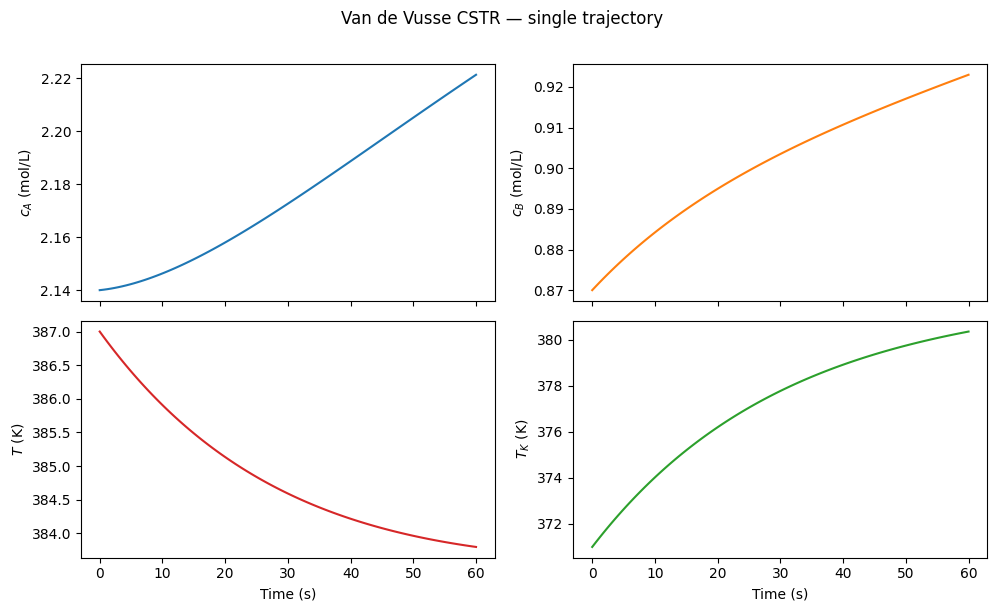

In [6]:
fig, axes = subplots(2, 2, figsize=(10, 6), sharex=True)

axes[0, 0].plot(t_s, c_A)
axes[0, 0].set_ylabel(r'$c_A$ (mol/L)')

axes[0, 1].plot(t_s, c_B, color='tab:orange')
axes[0, 1].set_ylabel(r'$c_B$ (mol/L)')

axes[1, 0].plot(t_s, T, color='tab:red')
axes[1, 0].set_ylabel(r'$T$ (K)')
axes[1, 0].set_xlabel('Time (s)')

axes[1, 1].plot(t_s, T_K, color='tab:green')
axes[1, 1].set_ylabel(r'$T_K$ (K)')
axes[1, 1].set_xlabel('Time (s)')

suptitle('Van de Vusse CSTR — single trajectory', y=1.01)
tight_layout()
show()

## 4. Dataset Generation

Generate 100 trajectories using Latin Hypercube sampling (LHS) over the operating ranges
from Table 4. Initial conditions and constant inputs are sampled jointly.

Each trajectory covers $t \in [0, 60]$ s at $\Delta t = 0.6$ s (101 points),
matching the data generation protocol of Velioglu et al.

| Variable | lb | ub | Unit |
|----------|----|----|------|
| $c_A(t_0)$ | 2.14 | 2.57 | mol/L |
| $c_B(t_0)$ | 0.87 | 1.09 | mol/L |
| $T(t_0)$ | 387 | 403 | K |
| $T_K(t_0)$ | 371 | 386 | K |
| $D = \dot{V}/V_R$ | 5 | 28.4 | 1/h |
| $\dot{Q}_K$ | −2227 | 0 | kJ/h |

In [7]:
from scipy.stats.qmc import LatinHypercube

# Operating ranges — Table 4 (initial value bounds)
# columns: [c_A, c_B, T, T_K, D, Q_dot_K]
lb = np.array([2.14,  0.87, 387.0, 371.0,    5.0, -2227.0])
ub = np.array([2.57,  1.09, 403.0, 386.0,   28.4,     0.0])

N_traj = 100
t_span = (0.0, 60 / 3600)                  # 60 s in hours
t_eval = np.linspace(*t_span, 101)         # Δt = 0.6 s

# Latin Hypercube sample: N_traj × 6 parameters
sampler = LatinHypercube(d=6, seed=42)
lhs = sampler.random(N_traj)               # uniform [0, 1]
params = lb + lhs * (ub - lb)             # scale to operating ranges

# Storage: states (N_traj, 101, 4), inputs (N_traj, 2)
X  = np.zeros((N_traj, 101, 4))
U  = params[:, 4:]                        # [D, Q_dot_K]
X0 = params[:, :4]                        # initial conditions

for i, (x0_i, u_i) in enumerate(zip(X0, U)):
    sol_i = solve_ivp(
        vdv, t_span, x0_i,
        args=(u_i[0], u_i[1]),
        t_eval=t_eval,
    )
    X[i] = sol_i.y.T   # (101, 4)

t_s = t_eval * 3600    # seconds, for plotting / saving
print(f"Generated {N_traj} trajectories — X shape: {X.shape}")

Generated 100 trajectories — X shape: (100, 101, 4)


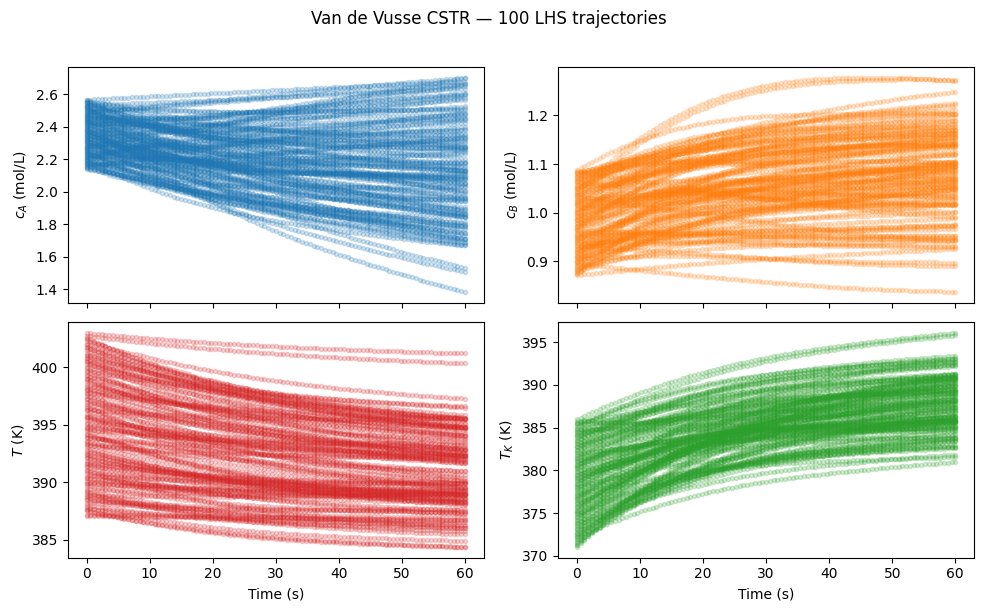

In [8]:
# Plot a sample of trajectories for each state
state_labels = [r'$c_A$ (mol/L)', r'$c_B$ (mol/L)', r'$T$ (K)', r'$T_K$ (K)']
colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']

fig, axes = subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, j, label, color in zip(axes.flat, range(4), state_labels, colors):
    for i in range(N_traj):
        ax.plot(t_s, X[i, :, j], '.', ms=6, color=color, alpha=0.2)
    ax.set_ylabel(label)

axes[1, 0].set_xlabel('Time (s)')
axes[1, 1].set_xlabel('Time (s)')
suptitle(f'Van de Vusse CSTR — {N_traj} LHS trajectories', y=1.01)
tight_layout()
show()

## 5. Record True Rate Constants

In Velioglu et al, PINN-C treats $k_1, k_2, k_3$ as unknown algebraic states to be inferred.
Since the data was generated with the full Arrhenius model, the true $k_i(t)$ are known:

$$k_i^{\text{true}}(t) = k_{i0}\exp\!\left(\frac{E_{a,i}}{T(t)}\right)$$

Taking logarithms gives the **Arrhenius plot** — linear in $1/T$:

$$\ln k_i = \ln k_{i0} + E_{a,i} \cdot \frac{1}{T}$$

This is the relationship PINN-C should recover without having been told the functional form.

In [9]:
T_all  = X[:, :, 2]       # (100, 101)
inv_T  = 1 / T_all

k_true = np.stack([
    arrhenius(T_all, k10, Ea1),
    arrhenius(T_all, k20, Ea2),
    arrhenius(T_all, k30, Ea3),
], axis=-1)   # (100, 101, 3)


D = U[:, 0]                      # (100,), sampled dilution rate [1/h]


D_all = D[:, None]                        # (100, 1), for broadcasting over time

# Intrinsic reaction rates
r1 = k_true[:, :, 0] * X[:, :, 0]         # r1 = k1 * c_A
r2 = k_true[:, :, 1] * X[:, :, 1]         # r2 = k2 * c_B
r3 = k_true[:, :, 2] * X[:, :, 0]**2      # r3 = k3 * c_A^2
reaction_rates_true = np.stack([r1, r2, r3], axis=-1)   # (100, 101, 3)

# Net CSTR species rates from mass balances (Eqs. 3a, 3b)
rates_true = np.stack([
    D_all * (c_A_in - X[:, :, 0]) - r1 - r3,   # dc_A/dt
    -D_all * X[:, :, 1] + r1 - r2,             # dc_B/dt
    -D_all * X[:, :, 2] + r3                    # dc_C/dt
], axis=-1)   # (100, 101, 3)



### Time History

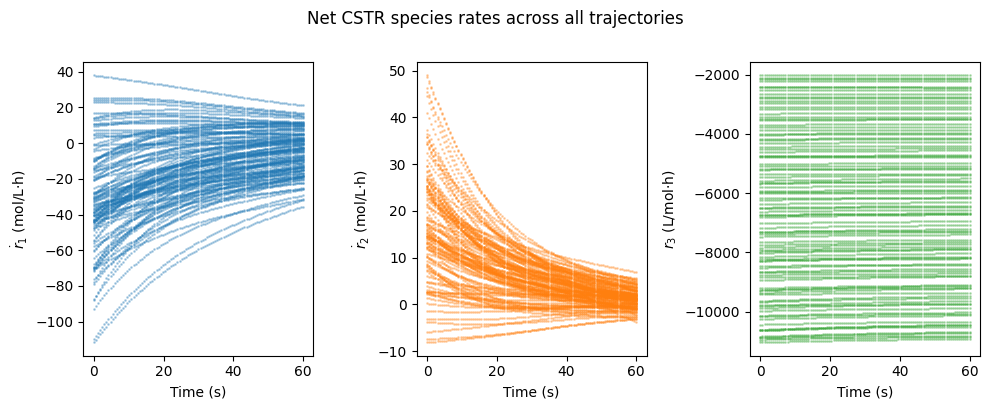

In [13]:
fig, axes = subplots(1, 3, figsize=(10, 4))
rate_labels = [r'$\dot{r}_1$ (mol/L·h)', r'$\dot{r}_2$ (mol/L·h)',r'$r_3$ (L/mol·h)']
colors = ['tab:blue', 'tab:orange','tab:green']

for ax, j, label, color in zip(axes, [0, 1, 2], rate_labels, colors):
    for i in range(N_traj):
        ax.plot(t_s, rates_true[i, :, j], '.', ms=2, color=color, alpha=0.3)
    ax.set_ylabel(label)
    ax.set_xlabel('Time (s)')

suptitle('Net CSTR species rates across all trajectories', y=1.01)
tight_layout()
show()

I don't think these plots are directly comparable to Velioglu table 6, but the trends for r1 and r2 are all clearly approaching values of 0, indicating that the system is approaching steady state regardless of the initial condiations. 

### Arrhenius Plot

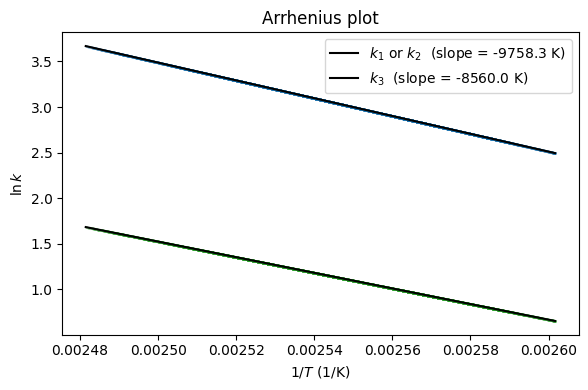

In [11]:
figure(figsize=(6, 4))

for j, (k0, Ea, color, label) in enumerate([
    (k10, Ea1, 'tab:blue',  r'$k_1$ or $k_2$'),
    (k30, Ea3, 'tab:green', r'$k_3$'),
]):
    idx = 0 if j == 0 else 2
    for i in range(N_traj):
        plot(inv_T[i], np.log(k_true[i, :, idx]), '.', ms=2, color=color, alpha=0.2)
    T_range = np.linspace(T_all.min(), T_all.max(), 200)
    plot(1/T_range, np.log(arrhenius(T_range, k0, Ea)),
         'k-', lw=1.5, label=f'{label}  (slope = {Ea:.1f} K)')

xlabel(r'$1/T$ (1/K)')
ylabel(r'$\ln k$')
title('Arrhenius plot')
legend()
tight_layout()
show()

In [12]:
# Save the dataset  for later comparison with PINN-C output
np.savez('vdv_dataset.npz', t=t_s, X=X, U=U, X0=X0, k_true=k_true)